In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


(2367, 11)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       123
           1       1.00      1.00      1.00       117
           2       0.97      0.99      0.98       113
           3       1.00      1.00      1.00       118
           4       0.99      0.98      0.99       121

    accuracy                           0.99       592
   macro avg       0.99      0.99      0.99       592
weighted avg       0.99      0.99      0.99       592



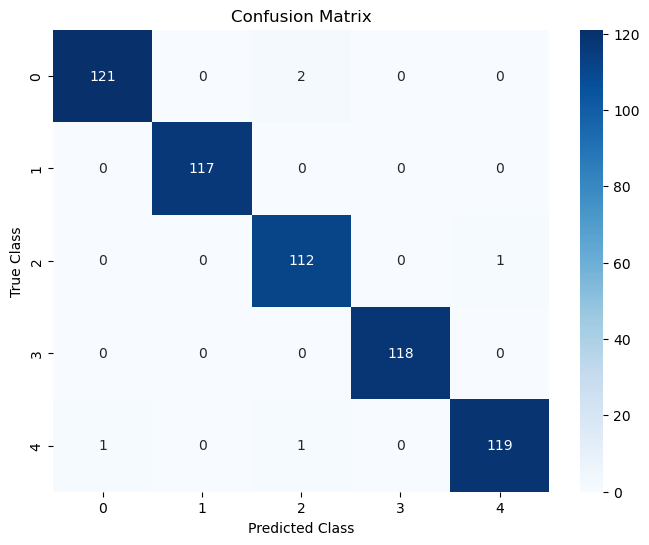

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("power_quality_fault_dataset.csv", index_col="ID")
print(df.shape)

# input features
X = df.drop(["Label","Fault_Type"], axis=1)


# output
y = df["Label"]


X = pd.get_dummies(X)

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# training 
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# prediction
y_pred = clf.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()


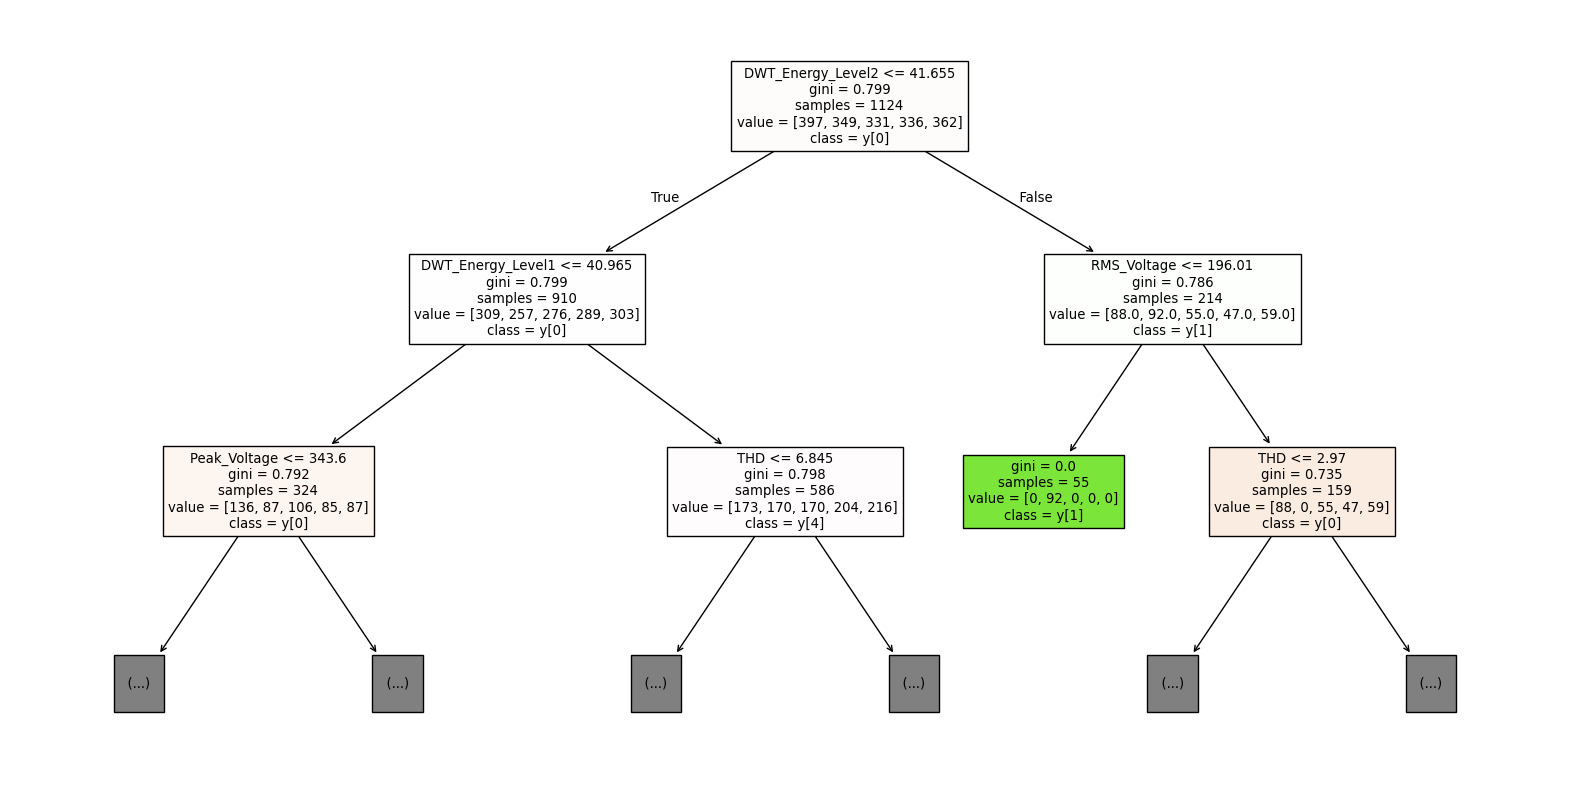

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    clf.estimators_[0],
    feature_names=X.columns,
    class_names=True,
    filled=True,
    max_depth=2
)
plt.show()


In [7]:
# training vs test accuracy 
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 1.0
Test Accuracy: 0.9915540540540541


Peak_Voltage             0.365349
RMS_Voltage              0.307976
THD                      0.269607
Duration_ms              0.011582
DWT_Entropy              0.010639
DWT_Energy_Level1        0.010530
Signal_Noise_Ratio_dB    0.010506
DWT_Energy_Level2        0.010128
Phase_C                  0.001407
Phase_A                  0.001196
Phase_B                  0.001079
dtype: float64


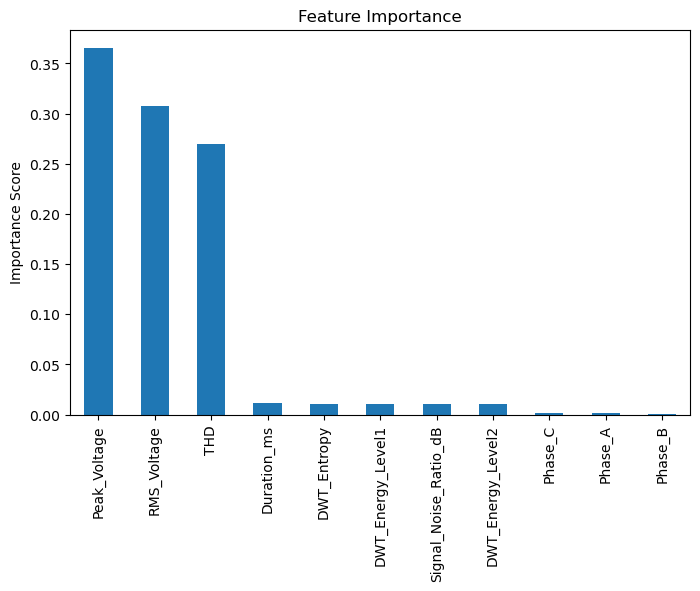

In [8]:
# feature importance
importance = pd.Series(clf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

# Plot
plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()